# 06 - SMC Zone Finder (ITF)
Order Blocks + Fair Value Gaps sa M15, filtered by H4 Bias

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)

print('Ready')

Ready


## 1. Fetch H4 (Bias) + M15 (Zones)
Kailangan natin pareho para i-filter ang zones ayon sa HTF bias

In [11]:
# H4 — for bias
h4 = mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_H4, 0, 500)
h4 = pd.DataFrame(h4)
h4['time'] = pd.to_datetime(h4['time'], unit='s')
h4 = h4.set_index('time')

# M15 — for OB / FVG zones (load more bars to find historical FVGs)
m15 = mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_M15, 0, 5000)
mt5.shutdown()
m15 = pd.DataFrame(m15)
m15['time'] = pd.to_datetime(m15['time'], unit='s')
m15 = m15.set_index('time')

print(f'H4:  {len(h4)} bars ({h4.index[0]} to {h4.index[-1]})')
print(f'M15: {len(m15)} bars ({m15.index[0]} to {m15.index[-1]})')

H4:  500 bars (2026-02-03 20:00:00 to 2026-06-01 00:00:00)
M15: 5000 bars (2026-03-18 23:45:00 to 2026-06-01 01:30:00)


## 2. H4 Bias Engine (from Week 1)

In [12]:
def find_swings(df, left=2, right=2):
    highs = []; lows = []
    for i in range(left, len(df) - right):
        wh = df['high'].iloc[i-left:i+right+1]
        wl = df['low'].iloc[i-left:i+right+1]
        if df['high'].iloc[i] == wh.max():
            highs.append({'index': df.index[i], 'price': df['high'].iloc[i]})
        if df['low'].iloc[i] == wl.min():
            lows.append({'index': df.index[i], 'price': df['low'].iloc[i]})
    return highs, lows

h4_highs, h4_lows = find_swings(h4)

current_close = h4['close'].iloc[-1]
prev_high = h4_highs[-2]['price'] if len(h4_highs) >= 2 else None
prev_low = h4_lows[-2]['price'] if len(h4_lows) >= 2 else None

if prev_high and current_close > prev_high:
    h4_bias = 'bullish'
elif prev_low and current_close < prev_low:
    h4_bias = 'bearish'
else:
    h4_bias = 'neutral'

print(f'H4 BIAS: {h4_bias.upper()}')
print(f'Current close: {current_close:.5f}')
if prev_high: print(f'Prev swing high: {prev_high:.5f}')
if prev_low:  print(f'Prev swing low:  {prev_low:.5f}')

H4 BIAS: NEUTRAL
Current close: 1.16525
Prev swing high: 1.16607
Prev swing low:  1.15856


## 3. Fair Value Gap (FVG) Detector — M15
3-candle pattern kung saan may **gap** between candle 1 and candle 3

In [13]:
def find_fvg(df, min_gap=0.00005):
    """Find Fair Value Gaps.
    Bullish FVG: c3.low > c1.high → gap = c1.high → c3.low
    Bearish FVG: c3.high < c1.low → gap = c3.high → c1.low
    """
    fvgs, near_misses = [], []
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]

        if c3['low'] > c1['high']:
            gap_bot, gap_top = c1['high'], c3['low']
            gap_size = gap_top - gap_bot
            info = {'time': df.index[i], 'type': 'bullish_fvg', 'top': gap_top, 'bottom': gap_bot, 'size': gap_size, 'mid': (gap_top+gap_bot)/2}
            if gap_size >= min_gap:
                fvgs.append(info)
            else:
                near_misses.append(info)

        if c3['high'] < c1['low']:
            gap_bot, gap_top = c3['high'], c1['low']
            gap_size = gap_top - gap_bot
            info = {'time': df.index[i], 'type': 'bearish_fvg', 'top': gap_top, 'bottom': gap_bot, 'size': gap_size, 'mid': (gap_top+gap_bot)/2}
            if gap_size >= min_gap:
                fvgs.append(info)
            else:
                near_misses.append(info)

    return pd.DataFrame(fvgs) if fvgs else pd.DataFrame(), pd.DataFrame(near_misses) if near_misses else pd.DataFrame()

fvgs, near_misses = find_fvg(m15, min_gap=0.00005)  # 0.5 pip minimum
if len(fvgs) > 0:
    bullish = (fvgs['type'] == 'bullish_fvg').sum()
    bearish = (fvgs['type'] == 'bearish_fvg').sum()
    print(f'FVG found: {len(fvgs)} (Bullish: {bullish} | Bearish: {bearish})')
    display(fvgs.sort_values('time').tail(15))
else:
    print(f'No FVG >= 0.5 pips in {len(m15)} M15 bars.')
    if len(near_misses) > 0:
        sizes = near_misses['size'].describe()
        print(f'Near-misses: {len(near_misses)} (min={sizes["min"]:.6f}, mean={sizes["mean"]:.6f}, max={sizes["max"]:.6f})')
        display(near_misses.sort_values('size', ascending=False).head(10))
    else:
        print('No 3-candle gaps at all in this range — market is ranging.')

FVG found: 859 (Bullish: 401 | Bearish: 458)


,time,type,top,bottom,size,mid
844,2026-05-29 06:45:00,bearish_fvg,1.16392,1.16385,0.00007,1.163885
845,2026-05-29 08:15:00,bullish_fvg,1.16407,1.16387,0.00020,1.163970
846,2026-05-29 09:15:00,bullish_fvg,1.16444,1.16422,0.00022,1.164330
847,2026-05-29 09:45:00,bullish_fvg,1.16481,1.16472,0.00009,1.164765
848,2026-05-29 10:30:00,bearish_fvg,1.16480,1.16439,0.00041,1.164595
849,2026-05-29 11:15:00,bearish_fvg,1.16391,1.16385,0.00006,1.163880
850,2026-05-29 13:00:00,bullish_fvg,1.16373,1.16367,0.00006,1.163700
851,2026-05-29 17:45:00,bullish_fvg,1.16463,1.16458,0.00005,1.164605
852,2026-05-29 18:00:00,bullish_fvg,1.16668,1.16476,0.00192,1.165720
853,2026-05-29 19:15:00,bearish_fvg,1.16752,1.16704,0.00048,1.167280


## 4. Order Block (OB) Detector — M15
Last candle bago ang impulsive move = Order Block

In [14]:
def find_order_blocks(df, impulse_min_pips=0.0010):
    """Find Order Blocks.
    Bullish OB = last bearish candle before a strong bullish impulse
    Bearish OB = last bullish candle before a strong bearish impulse
    """
    obs = []
    for i in range(1, len(df) - 1):
        prev = df.iloc[i-1]
        curr = df.iloc[i]

        # Bullish OB — bearish candle (prev) followed by strong bullish move (curr)
        if prev['close'] < prev['open']:  # bearish candle
            impulse = curr['close'] - curr['open']
            if impulse >= impulse_min_pips:
                obs.append({
                    'time': df.index[i],
                    'type': 'bullish_ob',
                    'top': max(prev['open'], prev['close']),
                    'bottom': min(prev['open'], prev['close']),
                    'impulse': impulse,
                    'mid': (max(prev['open'], prev['close']) + min(prev['open'], prev['close'])) / 2
                })

        # Bearish OB — bullish candle (prev) followed by strong bearish move (curr)
        if prev['close'] > prev['open']:  # bullish candle
            impulse = curr['open'] - curr['close']
            if impulse >= impulse_min_pips:
                obs.append({
                    'time': df.index[i],
                    'type': 'bearish_ob',
                    'top': max(prev['open'], prev['close']),
                    'bottom': min(prev['open'], prev['close']),
                    'impulse': impulse,
                    'mid': (max(prev['open'], prev['close']) + min(prev['open'], prev['close'])) / 2
                })

    return pd.DataFrame(obs) if obs else pd.DataFrame()

obs = find_order_blocks(m15, impulse_min_pips=0.0010)
if len(obs) > 0:
    bullish = (obs['type'] == 'bullish_ob').sum()
    bearish = (obs['type'] == 'bearish_ob').sum()
    print(f'OB found: {len(obs)} (Bullish: {bullish} | Bearish: {bearish})')
    obs.tail(10)
else:
    print('No OB found')

OB found: 81 (Bullish: 48 | Bearish: 33)


## 5. Combine — Filter Zones with H4 Bias
Kung H4 bullish, bullish OB/FVG lang ang gagamitin

In [15]:
def filter_zones_by_bias(obs, fvgs, bias):
    """Keep only zones that match HTF bias."""
    if bias == 'bullish':
        valid_obs = obs[obs['type'] == 'bullish_ob'].copy() if len(obs) > 0 else pd.DataFrame()
        valid_fvg = fvgs[fvgs['type'] == 'bullish_fvg'].copy() if len(fvgs) > 0 else pd.DataFrame()
    elif bias == 'bearish':
        valid_obs = obs[obs['type'] == 'bearish_ob'].copy() if len(obs) > 0 else pd.DataFrame()
        valid_fvg = fvgs[fvgs['type'] == 'bearish_fvg'].copy() if len(fvgs) > 0 else pd.DataFrame()
    else:  # neutral — show both
        valid_obs = obs.copy() if len(obs) > 0 else pd.DataFrame()
        valid_fvg = fvgs.copy() if len(fvgs) > 0 else pd.DataFrame()

    return valid_obs, valid_fvg

valid_obs, valid_fvg = filter_zones_by_bias(obs, fvgs, h4_bias)

print(f'H4 Bias: {h4_bias.upper()}')
print(f'Valid OB:  {len(valid_obs)}')
print(f'Valid FVG: {len(valid_fvg)}')

if len(valid_obs) > 0 or len(valid_fvg) > 0:
    print(f'\n{h4_bias.upper()} setups available — check M15 chart for zones')
else:
    print(f'No {h4_bias} setups found. Wait for price to create zones.')

H4 Bias: NEUTRAL
Valid OB:  81
Valid FVG: 859

NEUTRAL setups available — check M15 chart for zones


## 6. Overlapping Zones (Strongest Signals)
Kapag OB at FVG magkalapit = **confluence zone** (malakas na signal)

In [16]:
def find_overlapping_zones(obs, fvgs, max_distance=0.0005):
    """Find OB + FVG na magkalapit (confluence)."""
    if len(obs) == 0 or len(fvgs) == 0:
        return pd.DataFrame()

    overlaps = []
    for _, ob in obs.iterrows():
        for _, fvg in fvgs.iterrows():
            if ob['type'].split('_')[0] != fvg['type'].split('_')[0]:
                continue
            distance = abs(ob['mid'] - fvg['mid'])
            if distance <= max_distance:
                overlaps.append({
                    'time': max(ob['time'], fvg['time']),
                    'direction': ob['type'].split('_')[0],
                    'ob_top': ob['top'],
                    'ob_bottom': ob['bottom'],
                    'fvg_top': fvg['top'],
                    'fvg_bottom': fvg['bottom'],
                    'zone_top': max(ob['top'], fvg['top']),
                    'zone_bottom': min(ob['bottom'], fvg['bottom']),
                    'zone_mid': (max(ob['top'], fvg['top']) + min(ob['bottom'], fvg['bottom'])) / 2
                })

    return pd.DataFrame(overlaps).sort_values('time') if overlaps else pd.DataFrame()

confluence = find_overlapping_zones(valid_obs, valid_fvg)
if len(confluence) > 0:
    print(f'CONFLUENCE ZONES: {len(confluence)}')
    for _, cz in confluence.tail(5).iterrows():
        print(f"  {cz['time']} | {cz['direction']} | ${cz['zone_mid']:.5f}")
else:
    print('No overlapping OB + FVG zones found')

CONFLUENCE ZONES: 1086
  2026-05-29 13:00:00 | bullish | $1.16370
  2026-05-29 13:00:00 | bullish | $1.16330
  2026-05-29 13:00:00 | bullish | $1.16337
  2026-05-29 19:15:00 | bearish | $1.16742
  2026-05-29 19:15:00 | bearish | $1.16728


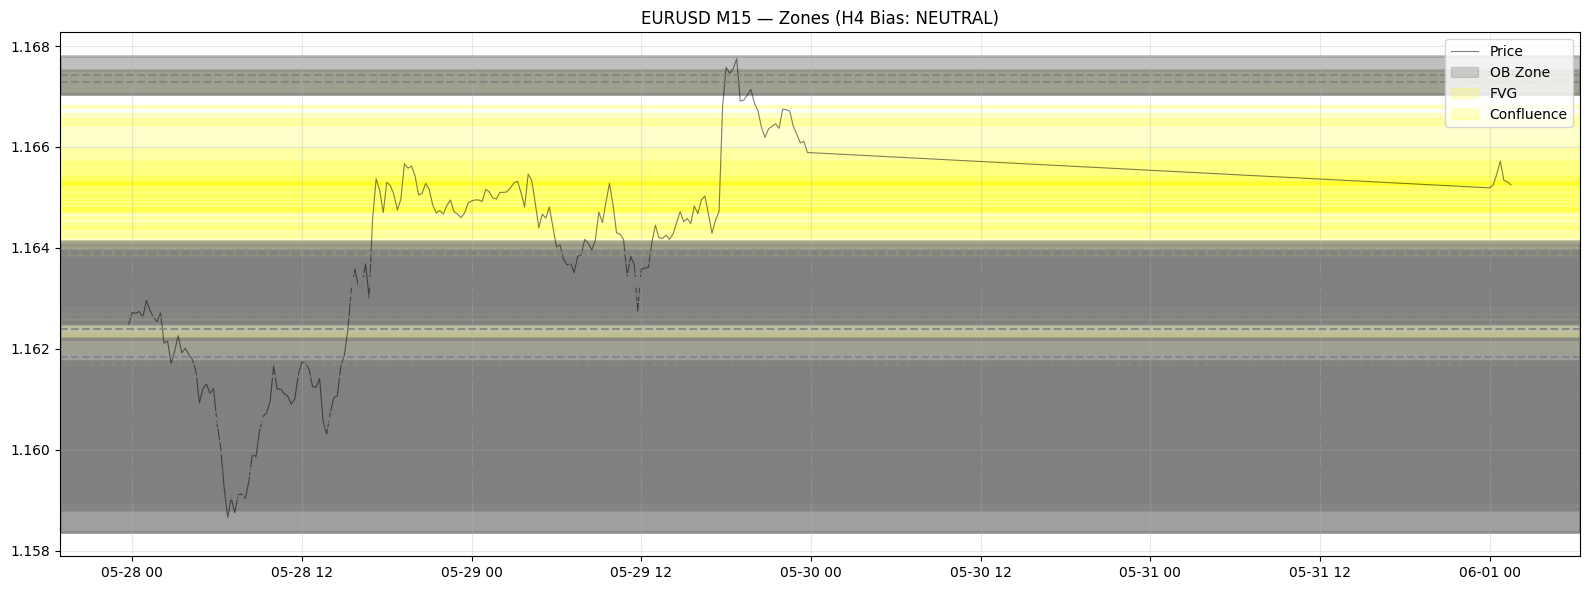

In [17]:
# Visualize — M15 with zones, colored by H4 bias
fig, ax = plt.subplots(figsize=(16, 6))

plot_m15 = m15.tail(200)
ax.plot(plot_m15.index, plot_m15['close'], color='black', linewidth=0.8, alpha=0.5)

zone_color = 'green' if h4_bias == 'bullish' else 'red' if h4_bias == 'bearish' else 'gray'

# Plot zones
if len(valid_obs) > 0:
    recent_obs = valid_obs[valid_obs['time'] >= plot_m15.index[0]]
    for _, ob in recent_obs.iterrows():
        ax.axhspan(ob['bottom'], ob['top'], alpha=0.3, color=zone_color)

if len(valid_fvg) > 0:
    recent_fvg = valid_fvg[valid_fvg['time'] >= plot_m15.index[0]]
    for _, fvg in recent_fvg.iterrows():
        ax.axhspan(fvg['bottom'], fvg['top'], alpha=0.2, color='yellow')

if len(confluence) > 0:
    recent_cz = confluence[confluence['time'] >= plot_m15.index[0]]
    for _, cz in recent_cz.iterrows():
        ax.axhspan(cz['zone_bottom'], cz['zone_top'], alpha=0.5, color=zone_color, linewidth=2)
        ax.axhline(y=cz['zone_mid'], color=zone_color, linestyle='--', alpha=0.8)

ax.set_title(f'EURUSD M15 — Zones (H4 Bias: {h4_bias.upper()})')
ax.legend(['Price', 'OB Zone', 'FVG', 'Confluence'], loc='best')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [18]:
# Summary
print('=' * 55)
print('SMC ZONE FINDER - SUMMARY')
print('=' * 55)
print(f'H4 Bias:     {h4_bias.upper()}')
print(f'Total OB:    {len(obs)} (Valid: {len(valid_obs)})')
print(f'Total FVG:   {len(fvgs)} (Valid: {len(valid_fvg)})')
print(f'Confluence:  {len(confluence)}')
print(f'=' * 55)

if h4_bias == 'bullish':
    print('Wait for price to retrace to OB/FVG zone')
    print('Look for bullish CHoCH on M1-M5 inside zone')
elif h4_bias == 'bearish':
    print('Wait for price to retrace to OB/FVG zone')
    print('Look for bearish CHoCH on M1-M5 inside zone')
else:
    print('H4 is neutral — wait for structure break first')
print('=' * 55)

SMC ZONE FINDER - SUMMARY
H4 Bias:     NEUTRAL
Total OB:    81 (Valid: 81)
Total FVG:   859 (Valid: 859)
Confluence:  1086
H4 is neutral — wait for structure break first
